# EQUITY — Feature Importance Analysis (Sreeram_experimental)

Per-asset-class cluster importance under the Jay-CSV labels.
Follows Harry's workflow: cluster MDA + MDI + SHAP, cross-method
rank agreement, within-cluster PCA + SHAP breakdown for top clusters,
global per-feature SHAP, and a pruned-vs-full CPCV(6,2) AUC
comparison.

All artifacts come from
`results/submission/importance/equity/` — produced
by `python -m stml.experimental.make_importance` (cluster summary)
and `python -m stml.experimental.make_importance_deep` (within-cluster
+ global SHAP + pruned-model comparison).


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

ASSET_CLASS = 'equity'
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists():
    REPO = REPO.parent
OUT = REPO / 'results' / 'submission' / 'importance' / ASSET_CLASS
print('Loading from:', OUT)


Loading from: /Volumes/Sreeram/Systematic/stml/results/submission/importance/equity


## 1. Cluster cross-check

Cluster ranks under each importance method, plus the
`significant` flag (MDA mean > 1 sigma above zero -> lower CI > 0).


In [2]:
crosscheck = pd.read_csv(OUT / 'cluster_crosscheck_table.csv')
crosscheck


,cluster_id,n_members,members,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,6,6,"f1_bb_pctb_20,f1_rsi_14,f6_ts_momentum_20,f10_...",0.013251,1,0.117779,2,0.329415,2,False
1,16,4,"f7_overnight_gap,f8_dow_sin,f8_dow_cos,f10_oc_ret",0.009736,2,0.064774,8,0.262699,4,True
2,4,4,"f6_ts_momentum_60,f6_ma_cross_20_60,f6_macd_12...",0.005659,3,0.072365,5,0.184979,5,False
3,14,3,"f5_trailing_run_length,f5_signal_entropy_20,f5...",0.003934,4,0.040095,13,0.138758,11,True
4,1,3,"f11_dxy_chg20,f11_eurusd_chg20,f11_dxy_chg5",0.002680,5,0.064989,7,0.151259,8,False
5,9,2,"f7_volume_z_20,f7_volume_trend_20",0.001821,6,0.051061,10,0.145766,10,False
6,3,9,"f18_term_spread_z63,f2_vol_ratio_20_60,f21_gol...",0.001557,7,0.134999,1,0.415065,1,False
7,13,2,"f12_variance_ratio_5_21,f12_autocorr_21",0.001394,8,0.040872,12,0.118210,12,False
8,2,5,"f5_participation_60,f11_ust2_rank63,f11_be10y_...",0.001131,9,0.066798,6,0.154892,6,False
9,7,5,"f19_atm_iv_1m,f19_atm_iv_3m,f19_skew_1m,f2_vol...",0.000657,10,0.073743,4,0.149759,9,False


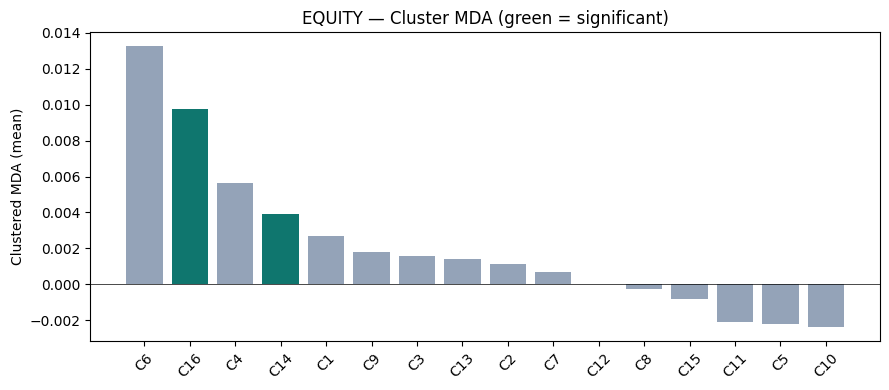

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(crosscheck))
ax.bar(x, crosscheck['mda_mean'],
       color=['#0F766E' if s else '#94a3b8' for s in crosscheck['significant']])
ax.set_xticks(x)
ax.set_xticklabels([f'C{int(c)}' for c in crosscheck['cluster_id']], rotation=45)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Clustered MDA (mean)')
ax.set_title('EQUITY — Cluster MDA (green = significant)')
plt.tight_layout(); plt.show()


## 2. Kendall rank agreement (MDA vs MDI vs SHAP)

Rank agreement across the three importance methods.
tau ~ 0.7+: methods agree (the typical pattern is MDI <-> SHAP).
tau < 0.4: methods disagree (typical: MDA <-> SHAP, since MDA is
the out-of-sample reality check).


In [4]:
rank_agree = pd.read_csv(OUT / 'rank_agreement.csv')
rank_agree


,metric_a,metric_b,kendall_tau,p_value
0,mdi_sum_mean,mda_mean,0.250000,0.194917
1,gain_sum_mean,mda_mean,0.250000,0.194917
2,mdi_sum_mean,gain_sum_mean,1.000000,0.000000
3,shap_sum_mean,mda_mean,0.383333,0.041262
4,shap_sum_mean,mdi_sum_mean,0.766667,0.000005


## 3. Within-cluster breakdown (top clusters by MDA)

For each top cluster: cluster members ranked by mean |SHAP|,
plus the PC1/PC2/PC3 loadings from a PCA fit on standardised
members. `pca_pc1_var_explained` >= 65% indicates a single latent
dimension (one representative suffices); 40-65% indicates a dominant
direction; < 40% indicates multi-dimensional structure.


In [5]:
import glob
wc_paths = sorted(glob.glob(str(OUT / 'within_cluster_C*.csv')))
wc_paths


['/Volumes/Sreeram/Systematic/stml/results/submission/importance/equity/within_cluster_C16_f10.csv',
 '/Volumes/Sreeram/Systematic/stml/results/submission/importance/equity/within_cluster_C1_f10.csv',
 '/Volumes/Sreeram/Systematic/stml/results/submission/importance/equity/within_cluster_C3_f1.csv',
 '/Volumes/Sreeram/Systematic/stml/results/submission/importance/equity/within_cluster_C4_f6.csv',
 '/Volumes/Sreeram/Systematic/stml/results/submission/importance/equity/within_cluster_C6_f1.csv',
 '/Volumes/Sreeram/Systematic/stml/results/submission/importance/equity/within_cluster_C8_f10.csv']

In [6]:
for p in wc_paths:
    name = Path(p).stem.replace('within_cluster_', '')
    df = pd.read_csv(p)
    pc1 = df['pca_pc1_var_explained'].iloc[0] * 100
    pc2 = df['pca_pc2_var_explained'].iloc[0] * 100 if 'pca_pc2_var_explained' in df.columns else 0
    print(f'--- {name}: PC1 = {pc1:.1f}%, PC1+PC2 = {pc1+pc2:.1f}%, {len(df)} members ---')
    display(df)


--- C16_f10: PC1 = 27.5%, PC1+PC2 = 53.6%, 4 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f10_oc_ret,16,0.163897,0.692811,0.274707,0.072474,0.260941,0.063419,0.237587
1,f7_overnight_gap,16,0.145538,-0.086050,0.274707,0.721766,0.260941,0.684904,0.237587
2,f8_dow_sin,16,0.032351,0.462692,0.274707,0.535870,0.260941,-0.540161,0.237587
3,f8_dow_cos,16,0.013175,0.546374,0.274707,-0.432023,0.260941,0.484882,0.237587


--- C1_f10: PC1 = 62.8%, PC1+PC2 = 71.2%, 13 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f10_hl_range,1,0.218107,0.287814,0.627757,0.104171,0.084675,0.369801,0.062899
1,f21_copper_gold_ratio,1,0.074103,-0.227660,0.627757,-0.213305,0.084675,0.594635,0.062899
2,f12_hurst_100,1,0.060340,0.203407,0.627757,0.179387,0.084675,-0.437586,0.062899
3,f19_iv_term_slope,1,0.056219,-0.300539,0.627757,-0.024059,0.084675,-0.290538,0.062899
4,f19_iv_pctile_252,1,0.047913,0.278606,0.627757,0.289945,0.084675,-0.211374,0.062899
5,f19_skew_1m,1,0.043516,0.251185,0.627757,0.218390,0.084675,0.003370,0.062899
6,f19_iv_rv_spread_20,1,0.036363,-0.193168,0.627757,0.727067,0.084675,0.309996,0.062899
7,f18_term_spread,1,0.035658,-0.297420,0.627757,-0.074772,0.084675,-0.001928,0.062899
8,f2_vol_of_vol_20,1,0.028793,0.302790,0.627757,-0.328546,0.084675,0.160425,0.062899
9,f19_atm_iv_3m,1,0.027252,0.303327,0.627757,0.109716,0.084675,0.153154,0.062899


--- C3_f1: PC1 = 72.7%, PC1+PC2 = 81.7%, 7 members ---


...

,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f6_ts_momentum_60,4,0.047209,0.484588,0.845418,-0.552858,0.105358,0.661353,0.043785
1,f6_macd_signal_9,4,0.036293,0.521859,0.845418,0.369332,0.105358,-0.238112,0.043785
2,f6_macd_12_26,4,0.035907,0.495119,0.845418,0.599590,0.105358,0.266552,0.043785
3,f6_ma_cross_20_60,4,0.030652,0.497689,0.845418,-0.445459,0.105358,-0.659443,0.043785


--- C6_f1: PC1 = 76.2%, PC1+PC2 = 86.5%, 6 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f1_rsi_14,6,0.179338,0.428051,0.762493,0.436953,0.102218,-0.061101,0.06335
1,f15_semi_vol_ratio_20,6,0.110900,-0.389629,0.762493,0.118236,0.102218,0.868034,0.06335
2,f6_ts_momentum_20,6,0.102677,0.426654,0.762493,-0.426685,0.102218,0.138588,0.06335
3,f12_trend_tval_21,6,0.066436,0.409353,0.762493,-0.061080,0.102218,0.132646,0.06335
4,f10_oc_ret_mean_20,6,0.042059,0.409532,0.762493,-0.442177,0.102218,0.380210,0.06335
5,f1_bb_pctb_20,6,0.038158,0.384242,0.762493,0.643258,0.102218,0.247835,0.06335


--- C8_f10: PC1 = 69.7%, PC1+PC2 = 98.6%, 3 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f10_oc_ret,8,0.162313,-0.330905,0.697113,0.943641,0.288616,0.006667,0.014271
1,f7_volume_trend_20,8,0.093444,0.666600,0.697113,0.238744,0.288616,-0.706148,0.014271
2,f7_volume_z_20,8,0.051961,0.667942,0.697113,0.229224,0.288616,0.708033,0.014271


## 4. Global per-feature SHAP

Mean |SHAP|, signed mean SHAP, and MDI per feature on the
asset-class modelling sample. Top features here that aren't in any
significant cluster are candidates for the pruned model.


In [7]:
gshap = pd.read_csv(OUT / 'global_shap_summary.csv')
display(gshap.head(25))


,feature,shap_magnitude,shap_signed,mdi
0,f1_rsi_14,0.179338,-0.006907,0.018928
1,f10_oc_ret,0.163897,-0.004001,0.018614
2,f7_overnight_gap,0.145538,0.002829,0.015407
3,f18_term_chg5,0.130148,0.003698,0.015145
4,f11_dxy_chg5,0.126686,0.003728,0.019959
5,f12_variance_ratio_5_21,0.116788,0.000365,0.016688
6,f15_semi_vol_ratio_20,0.110900,-0.002499,0.017332
7,f7_oi_level,0.107369,-0.025780,0.014410
8,f6_ts_momentum_20,0.102677,0.001959,0.016034
9,f7_volume_trend_20,0.101761,-0.001768,0.016170


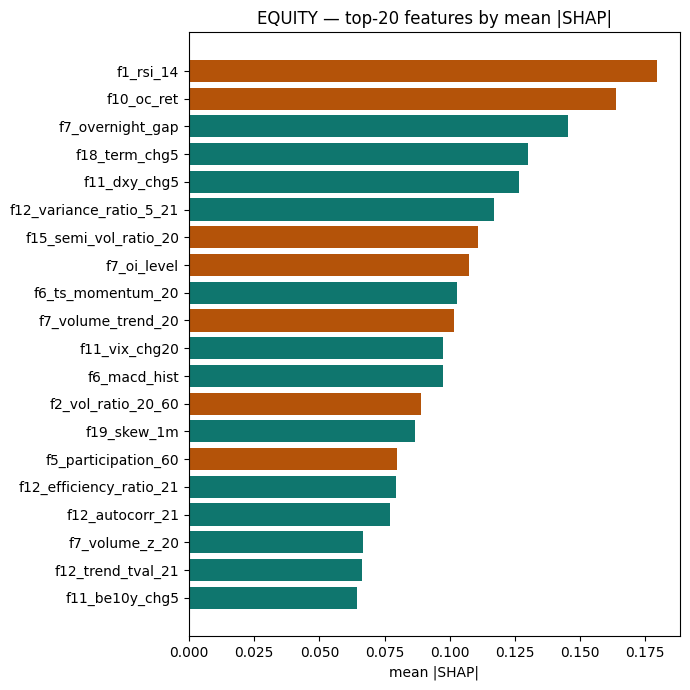

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
top = gshap.head(20).iloc[::-1]
colors = ['#0F766E' if v > 0 else '#B45309' for v in top['shap_signed']]
ax.barh(range(len(top)), top['shap_magnitude'], color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'])
ax.set_xlabel('mean |SHAP|')
ax.set_title('EQUITY — top-20 features by mean |SHAP|')
plt.tight_layout(); plt.show()


## 5. Pruned model — selection rule

Selection rule (per Harry / user spec):

1. For each significant cluster (MDA mean > 1 sigma):
   - PC1 >= 65% -> one representative (the top SHAP member).
   - PC1 + PC2 >= 75% -> two representatives.
   - Otherwise -> top-2 by mean |SHAP|.
2. Plus the global top-5 SHAP features not in any chosen cluster.


In [9]:
with open(OUT / 'pruned_features.json') as f:
    pruned = json.load(f)
print(f"Pruned feature set ({pruned['n_pruned']} features):")
for feat in pruned['features']:
    print(f"  - {feat:<35}  {pruned['reasons'][feat]}")


Pruned feature set (5 features):
  - f10_oc_ret                           cluster 16: PC1 27% multi-dim -> top-2 by SHAP
  - f7_overnight_gap                     cluster 16: PC1 27% multi-dim -> top-2 by SHAP
  - f1_rsi_14                            global SHAP top-5
  - f18_term_chg5                        global SHAP top-5
  - f11_dxy_chg5                         global SHAP top-5


## 6. Full vs pruned model — honest held-out val AUC

Importance + global SHAP + cluster selection all computed on the
**train** partition only. Pruned features picked from train.
Both models then fit on **train** and scored on the **held-out val**
partition (never used for selection). The val AUC reported here is
an honest out-of-sample estimate of the pruning effect.


In [10]:
cmp = pd.read_csv(OUT / 'pruned_vs_full_auc.csv')
cmp


,model,n_features,n_val,val_auc,val_sem
0,full,74,364,0.531975,0.030236
1,pruned,5,364,0.600906,0.029569


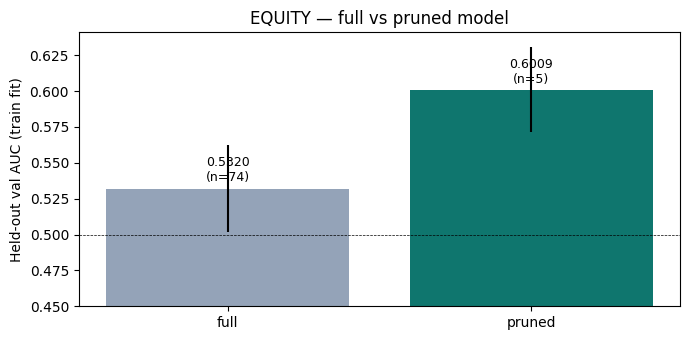

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(cmp['model'], cmp['val_auc'],
       yerr=cmp['val_sem'],
       color=['#94a3b8', '#0F766E'])
ax.axhline(0.5, color='black', linewidth=0.5, linestyle='--')
ax.set_ylim(0.45, max(cmp['val_auc']) + 0.04)
for i, (m, a, n) in enumerate(zip(cmp['model'], cmp['val_auc'], cmp['n_features'])):
    ax.text(i, a + 0.005, f'{a:.4f}\n(n={int(n)})', ha='center', fontsize=9)
ax.set_ylabel('Held-out val AUC (train fit)')
ax.set_title('EQUITY — full vs pruned model')
plt.tight_layout(); plt.show()


## 7. Findings note (plain-text summary)

Auto-generated summary: significant clusters, top SHAP features,
the pruned feature list, and the CPCV AUC comparison.


In [12]:
print((OUT / 'findings_note.txt').read_text())


=== EQUITY — feature importance findings ===

Modelling sample: 1083 events; 66 features after hygiene.
Significant clusters (MDA mean > 1 sigma): 2 of 16.

Top significant clusters (by MDA):
  C16: 4 members, MDA +0.0097 +/- 0.0000, top SHAP member = f10_oc_ret, PC1 var = 27%
  C14: 3 members, MDA +0.0039 +/- 0.0000, top SHAP member = ?, PC1 var = 0%

Top 10 global features by mean |SHAP|:
  f1_rsi_14                           |SHAP| = 0.1793
  f10_oc_ret                          |SHAP| = 0.1639
  f7_overnight_gap                    |SHAP| = 0.1455
  f18_term_chg5                       |SHAP| = 0.1301
  f11_dxy_chg5                        |SHAP| = 0.1267
  f12_variance_ratio_5_21             |SHAP| = 0.1168
  f15_semi_vol_ratio_20               |SHAP| = 0.1109
  f7_oi_level                         |SHAP| = 0.1074
  f6_ts_momentum_20                   |SHAP| = 0.1027
  f7_volume_trend_20                  |SHAP| = 0.1018

Pruned feature set (5 features):
  - f10_oc_ret  (cluster 16: PC1